Loading OMNI AE data...
AE data loaded.
Loading RBSP data...
Combining data...
Total samples: 21434088
Computing global scale...
Global max = 0.012860958579824732
Plotting AE < 100 nT (Quiet)
Saved: ./ugh_polar_ratio_plots_FINAL/3fin_RBSP_AE_0_100.png


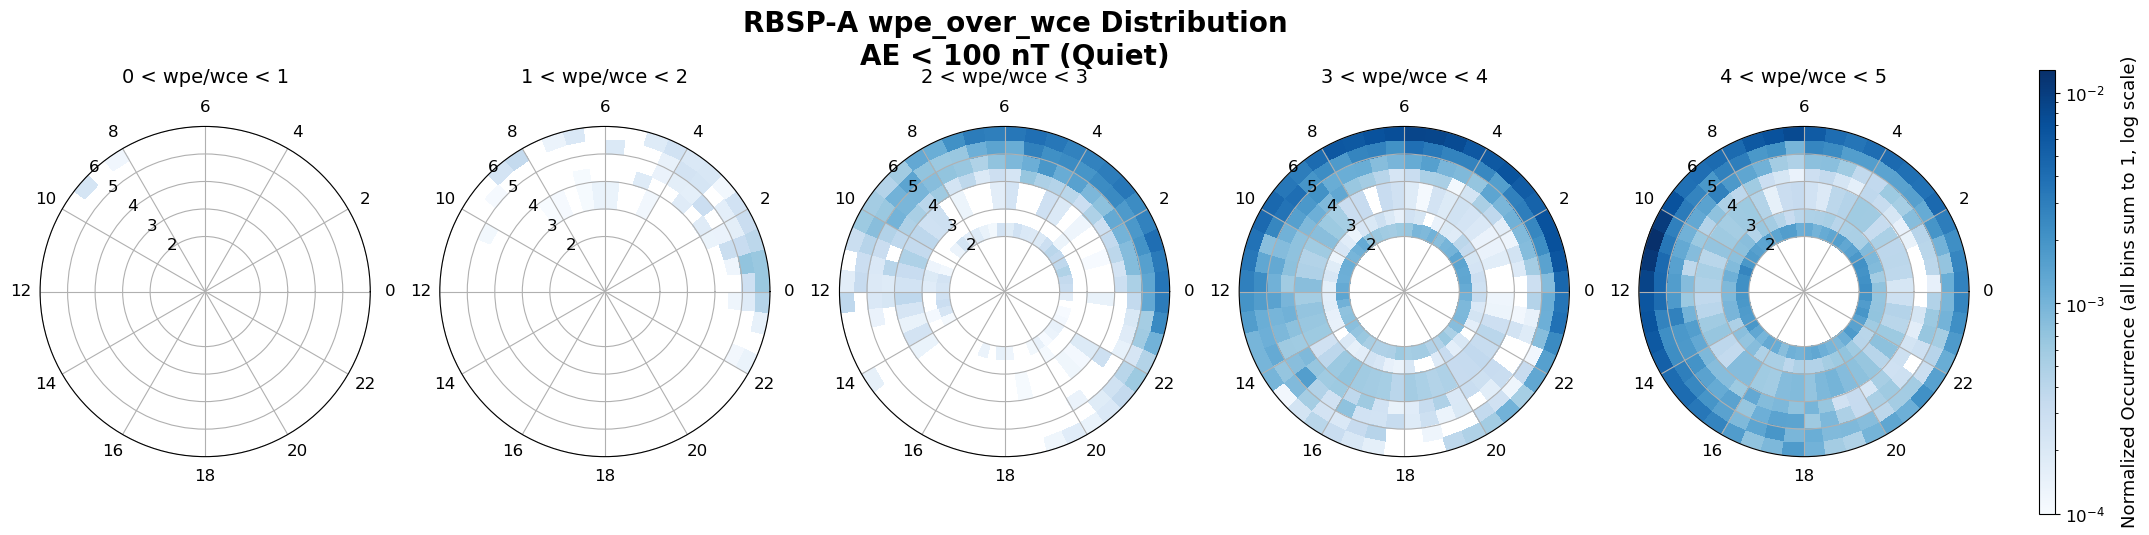

Plotting 100 < AE < 400 nT (Moderate)
Saved: ./ugh_polar_ratio_plots_FINAL/3fin_RBSP_AE_100_400.png


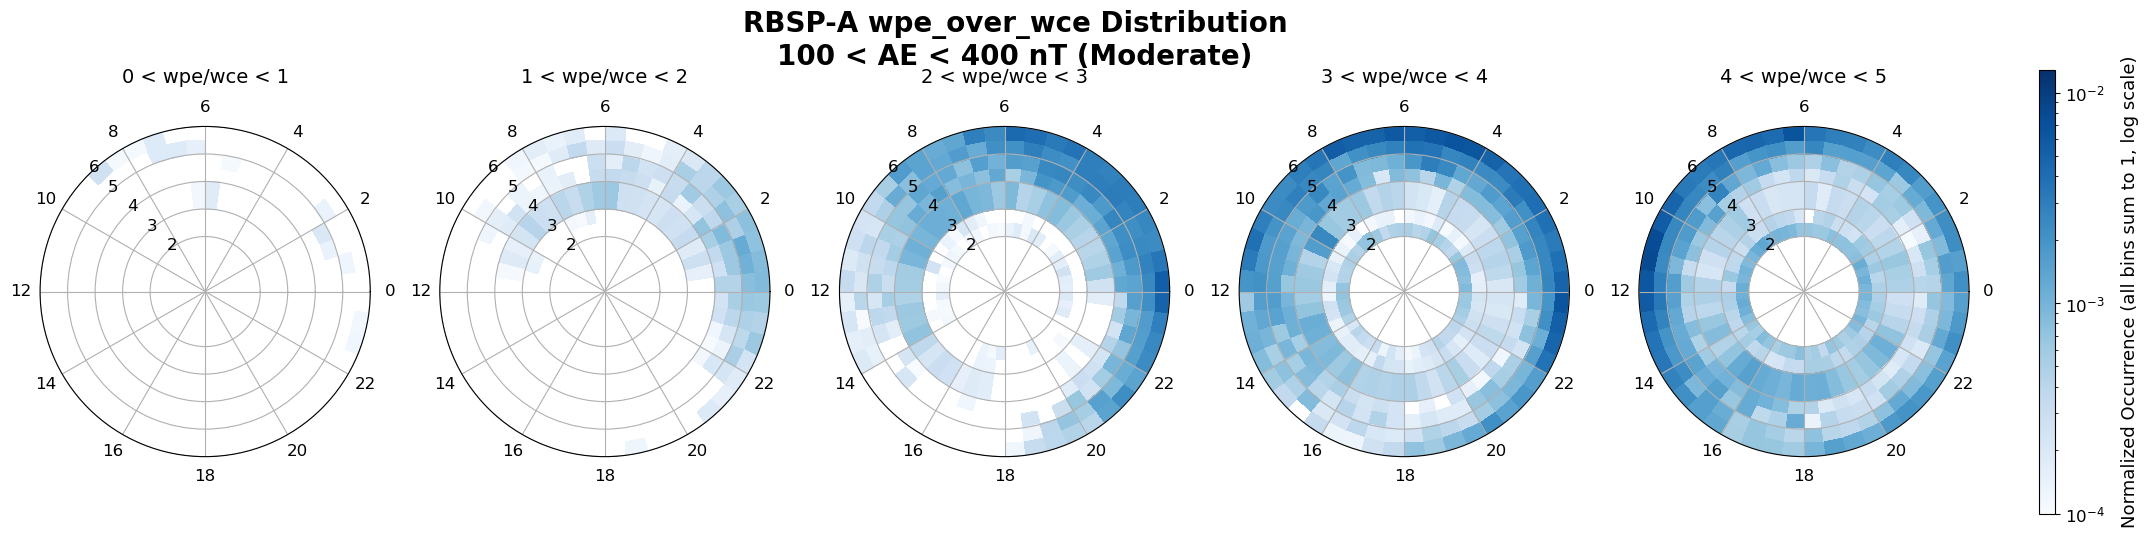

Plotting AE > 400 nT (Active)
Saved: ./ugh_polar_ratio_plots_FINAL/3fin_RBSP_AE_gt_400.png


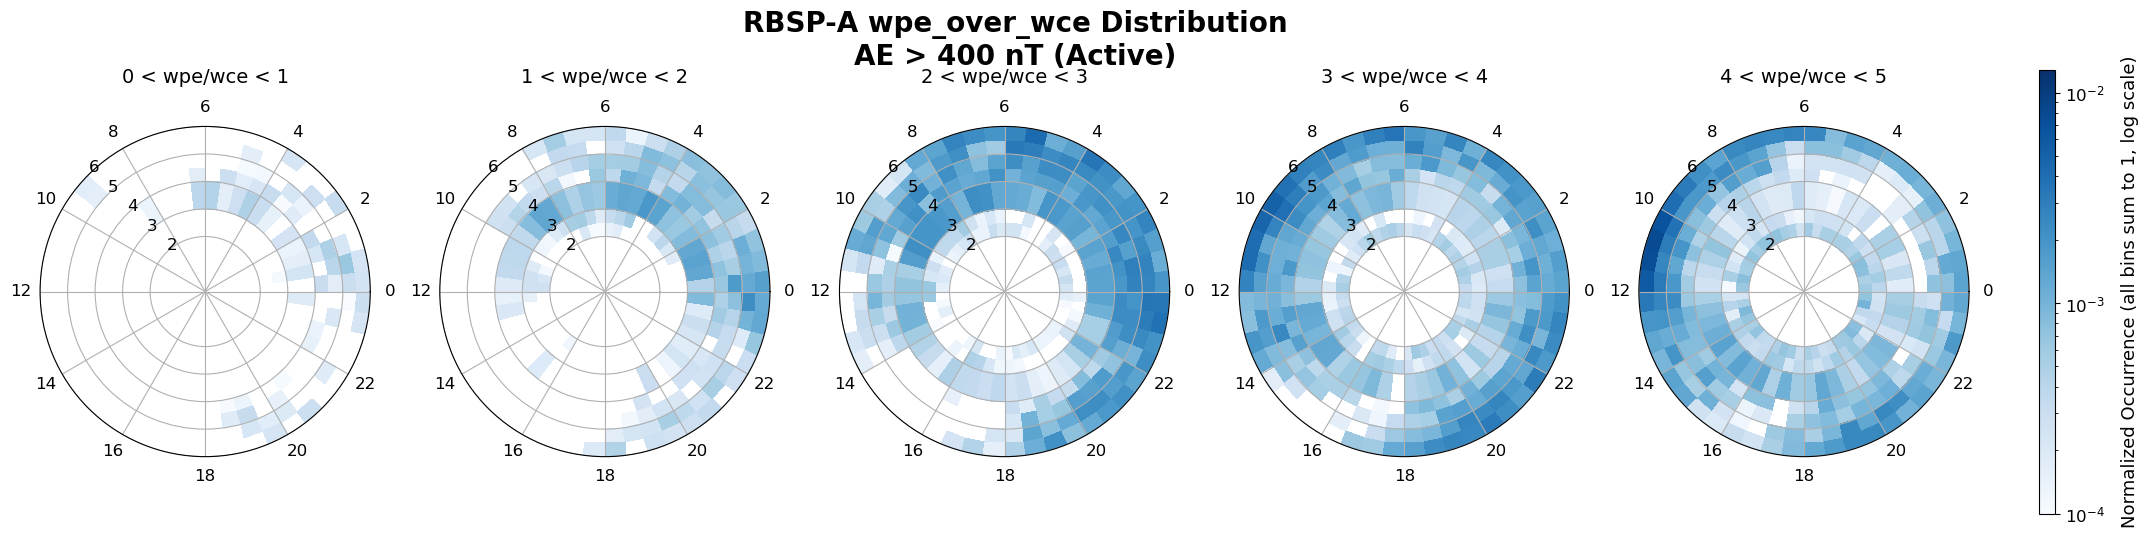

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
import cdflib
import glob
import re
from pathlib import Path
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

plt.rcParams.update({'font.size': 12})

# ------------------------------------------
# Paths
# ------------------------------------------
ROOT_L4   = "/project/rbsp/mirror/fm1/L4"
ROOT_MAGE = "/project/rbsp/soc/Server/ECT/MagEphem/RBSP-A/definitive"

OMNI_FILE = "omni_hros_1min_20120915000000_20191012000000_cdaweb.cdf"

YEAR_START = "2012-09-15"
YEAR_END   = "2019-10-12"

OUTDIR = "./ugh_polar_ratio_plots_FINAL"
Path(OUTDIR).mkdir(exist_ok=True)

# ------------------------------------------
# L range
# ------------------------------------------
L_MIN = 2.0
L_MAX = 6.0

# ------------------------------------------
# Smooth binning
# ------------------------------------------
abins = np.linspace(0, 2*np.pi, 49)
rbins = np.arange(L_MIN, L_MAX + 0.5, 0.5)
rbins = rbins[rbins != 3.5]

ratio_ranges = [(0,1),(1,2),(2,3),(3,4),(4,5)]
titles = [
    "0 < wpe/wce < 1",
    "1 < wpe/wce < 2",
    "2 < wpe/wce < 3",
    "3 < wpe/wce < 4",
    "4 < wpe/wce < 5"
]

AE_bins = [(0,100),(100,400),(400,10000)]
AE_titles = [
    "AE < 100 nT (Quiet)",
    "100 < AE < 400 nT (Moderate)",
    "AE > 400 nT (Active)"
]

# ==========================================
# Load OMNI AE
# ==========================================
print("Loading OMNI AE data...")

cdf_ae = cdflib.CDF(OMNI_FILE)
epoch = cdf_ae.varget("Epoch")
time_ae = pd.to_datetime(cdflib.cdfepoch.to_datetime(epoch)).tz_localize("UTC")
AE_vals = cdf_ae.varget("AE_INDEX")

AE_series = pd.Series(AE_vals, index=time_ae)

print("AE data loaded.")

# ==========================================
# MagEphem parsing
# ==========================================
def parse_start_columns(path):
    wanted = {"DateTime", "Lsimple", "Lm_eq", "CDMAG_MLT", "EDMAG_MLT"}
    cols = {}
    current = None

    with open(path, "r", errors="ignore") as f:
        for line in f:
            if not line.startswith("#"):
                break
            s = line[1:].strip()
            m = re.match(r'"([A-Za-z0-9_]+)"\s*:\s*{', s)
            if m:
                current = m.group(1)
            m = re.search(r'"START_COLUMN"\s*:\s*([0-9]+)', s)
            if m and current in wanted:
                cols[current] = int(m.group(1))
    return cols


def load_L_MLT_magEphem(path):
    sc = parse_start_columns(path)

    df = pd.read_csv(
        path,
        comment="#",
        header=None,
        sep=r"\s+|,",
        engine="python"
    )

    time = pd.to_datetime(df.iloc[:, sc["DateTime"]],
                          utc=True, errors="coerce")

    if "Lsimple" in sc:
        L = pd.to_numeric(df.iloc[:, sc["Lsimple"]], errors="coerce").to_numpy()
    else:
        L = pd.to_numeric(df.iloc[:, sc["Lm_eq"]], errors="coerce").to_numpy()

    if "CDMAG_MLT" in sc:
        MLT = pd.to_numeric(df.iloc[:, sc["CDMAG_MLT"]], errors="coerce").to_numpy()
    else:
        MLT = pd.to_numeric(df.iloc[:, sc["EDMAG_MLT"]], errors="coerce").to_numpy()

    return time, L, np.mod(MLT, 24.0)

# ==========================================
# Load RBSP Data
# ==========================================
all_ratio, all_L, all_MLT, all_AE = [], [], [], []

days = pd.date_range(YEAR_START, YEAR_END, freq="D")

print("Loading RBSP data...")

for day in days:
    y, m, d = f"{day.year:04d}", f"{day.month:02d}", f"{day.day:02d}"
    ymd = f"{y}{m}{d}"

    l4 = glob.glob(f"{ROOT_L4}/{y}/{m}/{d}/rbsp-a_density_emfisis-L4_{ymd}_v*.cdf")
    mg = glob.glob(f"{ROOT_MAGE}/{y}/rbspa*_MagEphem_*_{ymd}_v*.txt")

    if not l4 or not mg:
        continue

    try:
        cdf = cdflib.CDF(l4[0], validate=False)

        ratio = np.asarray(cdf.varget("wpe_over_wce"), float)

        tvar = cdf.varattsget("wpe_over_wce")["DEPEND_0"]
        if isinstance(tvar, bytes):
            tvar = tvar.decode()

        t_ratio = pd.to_datetime(
            cdflib.cdfepoch.to_datetime(cdf.varget(tvar)),
            utc=True
        )

        t_m, L, MLT = load_L_MLT_magEphem(mg[0])

        sL   = pd.Series(L, index=t_m)
        sMLT = pd.Series(MLT, index=t_m)

        L_i   = sL.reindex(t_ratio, method="nearest")
        MLT_i = sMLT.reindex(t_ratio, method="nearest")
        AE_i  = AE_series.reindex(t_ratio, method="nearest")

        good = (
            np.isfinite(ratio) &
            np.isfinite(L_i) &
            np.isfinite(MLT_i) &
            np.isfinite(AE_i) &
            (ratio > 0) &
            (L_i >= L_MIN) &
            (L_i <= L_MAX)
        )

        if np.sum(good) == 0:
            continue

        all_ratio.append(ratio[good])
        all_L.append(L_i[good].to_numpy())
        all_MLT.append(MLT_i[good].to_numpy())
        all_AE.append(AE_i[good].to_numpy())

    except Exception:
        continue

# ==========================================
# Combine
# ==========================================
print("Combining data...")

ratio = np.concatenate(all_ratio)
L     = np.concatenate(all_L)
MLT   = np.concatenate(all_MLT)
AE    = np.concatenate(all_AE)

theta = np.radians((MLT * 360.0) / 24.0)

print("Total samples:", ratio.size)

# ==========================================
# GLOBAL SCALE
# ==========================================
print("Computing global scale...")

global_max = 0

for (AEmin, AEmax) in AE_bins:

    AE_mask = (AE >= AEmin) & (AE < AEmax)

    total_mask = (ratio > 0) & (ratio < 5) & AE_mask
    total_count = np.sum(total_mask)

    if total_count == 0:
        continue

    for (rmin, rmax) in ratio_ranges:

        mask = (ratio > rmin) & (ratio < rmax) & AE_mask

        if np.sum(mask) == 0:
            continue

        counts, _, _, _ = binned_statistic_2d(
            theta[mask], L[mask],
            np.ones(np.sum(mask)),
            statistic="sum",
            bins=[abins, rbins]
        )

        counts = counts / total_count

        if np.any(np.isfinite(counts)):
            global_max = max(global_max, np.nanmax(counts))

print("Global max =", global_max)

# ==========================================
# Plot + Save (FIXED LAYOUT)
# ==========================================
for (AEmin, AEmax), AEtitle in zip(AE_bins, AE_titles):

    print(f"Plotting {AEtitle}")

    AE_mask = (AE >= AEmin) & (AE < AEmax)

    total_mask = (ratio > 0) & (ratio < 5) & AE_mask
    total_count = np.sum(total_mask)

    if total_count == 0:
        continue

    fig = plt.figure(figsize=(26, 6))
    gs = GridSpec(1, 6, width_ratios=[1,1,1,1,1,0.05], wspace=0.25)

    axes = [fig.add_subplot(gs[0, i], projection="polar") for i in range(5)]
    cax = fig.add_subplot(gs[0, 5])

    for ax, (rmin, rmax), title in zip(axes, ratio_ranges, titles):

        mask = (ratio > rmin) & (ratio < rmax) & AE_mask

        if np.sum(mask) == 0:
            continue

        counts, _, _, _ = binned_statistic_2d(
            theta[mask], L[mask],
            np.ones(np.sum(mask)),
            statistic="sum",
            bins=[abins, rbins]
        )

        counts = counts / total_count
        counts[counts < 1e-4] = np.nan

        pcm = ax.pcolormesh(
            abins, rbins, counts.T,
            cmap="Blues",
            norm=LogNorm(vmin=1e-4, vmax=global_max)
        )

        ax.set_theta_zero_location("E")
        ax.set_theta_direction(1)

        ax.set_xticks(np.linspace(0, 2*np.pi, 12, endpoint=False))
        ax.set_xticklabels(range(0, 24, 2))

        ax.set_rticks(np.arange(2, L_MAX + 1, 1))
        ax.set_rlabel_position(135)

        ax.grid(True)
        ax.set_title(title, fontsize=14, pad=12)

    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(
        "Normalized Occurrence (all bins sum to 1, log scale)",
        fontsize=13,
        labelpad=12
    )

    fig.suptitle(
        f"RBSP-A wpe_over_wce Distribution\n{AEtitle}",
        fontsize=20,
        fontweight="bold",
        y=0.95
    )

    fig.subplots_adjust(top=0.85)

    if AEmax == 10000:
        fname = f"{OUTDIR}/3fin_RBSP_AE_gt_{AEmin}.png"
    else:
        fname = f"{OUTDIR}/3fin_RBSP_AE_{AEmin}_{AEmax}.png"

    plt.savefig(fname, dpi=300)
    print(f"Saved: {fname}")

    plt.show()